## Stuff and foo

In [1]:
pwd

'/group/datalabgrp/ctbrown/2026-pancoding-core/notebooks'

In [2]:
import polars as pl
import glob
import os
import screed
import csv
import screed
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Read in the information mapping genes to species

In [3]:
seq_to_species_df = (
    pl.read_csv('../outputs.mapping/cds-min50-singleclust/species_to_genes.csv')
    .rename({ 'ident': 'gene' })
    .select(['gene', 'species'])
)
seq_to_species_df

gene,species
str,str
"""AtH2023_ERR1135319_MAG02_1_7""","""s__Bariatricus sp004560705"""
"""AtH2023_ERR1135319_MAG02_1_10""","""s__Bariatricus sp004560705"""
"""AtH2023_ERR1135319_MAG02_1_13""","""s__Bariatricus sp004560705"""
"""AtH2023_ERR1135319_MAG02_1_23""","""s__Bariatricus sp004560705"""
"""AtH2023_ERR1135319_MAG02_1_27""","""s__Bariatricus sp004560705"""
…,…
"""AtH2023_SRR8960831_MAG08_7_11""","""s__UBA2868 sp004552595"""
"""AtH2023_ERR1135443_MAG08_149_1""","""s__UBA2868 sp004552595"""
"""AtH2023_SRR14369154_MAG04_52_1…","""s__UBA2868 sp004552595"""


## Read in the mapping results to rand100

In [4]:
rand100_mapping_df = (
    pl.read_csv('../outputs.mapping/rand100-cds3.min50.depth.csv')
    .join(seq_to_species_df, on='gene', how='inner')
    .select(['metag', 'species', 'gene', 'depth_all'])
)
rand100_mapping_df

metag,species,gene,depth_all
str,str,str,f64
"""ERR3211766""","""s__Sodaliphilus sp004557565""","""AtH2023_SRR17241558_MAG08_494_…",2.160784
"""ERR3211766""","""s__UBA2868 sp004552595""","""AtH2023_SRR8960393_MAG18_22_28""",0.0
"""ERR3211766""","""s__Bariatricus sp004560705""","""AtH2023_SRR5240725_MAG08_283_1…",0.21393
"""ERR3211766""","""s__Sodaliphilus sp004557565""","""AtH2023_SRR11805640_MAG02_82_2""",9.953846
"""ERR3211766""","""s__Colivicinus sp002299675""","""AtH2023_SRR8960514_MAG08_39_2""",0.0
…,…,…,…
"""SRR11125751""","""s__Sodaliphilus sp004557565""","""AtH2023_SRR17241501_MAG14_158_…",17.160839
"""SRR11125751""","""s__Sodaliphilus sp004557565""","""AtH2023_SRR5976186_MAG02_155_2""",16.519298
"""SRR11125751""","""s__Cryptobacteroides sp0004349…","""AtH2023_SRR14369225_MAG28_14_6…",0.0


## Read in the manually curated species-specific genes

In [5]:
species_genes_df = (pl.read_csv('../inputs.genes/species-genes.csv')
    .filter(pl.col("anchor") == 1)
    .with_columns(pl.col('gene_name').alias('gene'))
    .select(["anchor", "gene", "species", "description"])
)

species_genes_df

anchor,gene,species,description
i64,str,str,str
1,"""AtH2023_SRR8960431_MAG03_43_3""","""s__Lactobacillus amylovorus""","""BLAST match to LD-transpeptida…"
1,"""AtH2023_SRR11126084_MAG3_16_2""","""s__Mogibacterium_A kristiansen…","""BLAST match to isolate genome"""
1,"""AtH2023_ERR3211826_MAG3_378_5""","""s__Sodaliphilus sp004557565""","""IG-like domain-containing prot…"
1,"""AtH2023_SRR8960669_MAG08_76_1""","""s__Cryptobacteroides sp9005469…","""Stealth CR1 domain-containing …"
1,"""AtH2023_SRR11489784_MAG01_15_2""","""s__Prevotella sp000434975""","""efflux RND transporter permeas…"
…,…,…,…
1,"""AtH2023_SRR8960594_MAG07_75_1""","""s__UBA2868 sp004552595""","""multiple monosaccharide ABC tr…"
1,"""AtH2023_SRR5240726_MAG15_114_6""","""s__Cryptobacteroides sp0340892…","""carbon starvation protein A [B…"
1,"""AtH2023_SRR8960403_MAG06_120_8""","""s__Cryptobacteroides sp0004349…","""hypothetical protein [Bacteroi…"


## Join the mapping results to the anchor genes

In [6]:
anchor_df = rand100_mapping_df.join(species_genes_df, on=['gene', 'species'], how='inner').drop('anchor')
anchor_df

metag,species,gene,depth_all,description
str,str,str,f64,str
"""ERR3211766""","""s__Mogibacterium_A kristiansen…","""AtH2023_SRR11126084_MAG3_16_2""",0.0,"""BLAST match to isolate genome"""
"""ERR3211766""","""s__UBA2868 sp004552595""","""AtH2023_SRR8960594_MAG07_75_1""",0.0,"""multiple monosaccharide ABC tr…"
"""ERR3211766""","""s__Cryptobacteroides sp0004349…","""AtH2023_SRR8960403_MAG06_120_8""",1.039331,"""hypothetical protein [Bacteroi…"
"""ERR3211766""","""s__Fimisoma sp002320005""","""AtH2023_SRR8960631_MAG16_82_35""",0.0,"""PEP/pyruvate-binding domain-co…"
"""ERR3211766""","""s__Colivicinus sp002299675""","""AtH2023_SRR8960562_MAG17_38_11""",0.088235,"""RNA lysidine(34) synthetase Ti…"
…,…,…,…,…
"""SRR11125751""","""s__Prevotella sp002251295""","""AtH2023_ERR3211937_MAG3_16_9""",0.927108,"""YfnO"""
"""SRR11125751""","""s__Lactobacillus amylovorus""","""AtH2023_SRR8960431_MAG03_43_3""",0.624352,"""BLAST match to LD-transpeptida…"
"""SRR11125751""","""s__Floccifex porci""","""AtH2023_SRR11126230_MAG2_46_3""",0.291126,"""anaerobic ribonucleoside-triph…"


## Bring in the k-mer coverage dataframes from the intersections analysis

In [7]:
kmer_df = (
    pl.read_csv('../outputs.isect/*.isect.abund.csv')
    .rename({'abund': 'kmer_abund'})
)
kmer_df

metag,species,kmer_abund
str,str,f64
"""ERR3212028""","""s__Bariatricus sp004560705""",1.84375
"""ERR3211889""","""s__Bariatricus sp004560705""",1.732068
"""SRR8960468""","""s__Bariatricus sp004560705""",1.964286
"""SRR8960622""","""s__Bariatricus sp004560705""",11.882
"""SRR11126389""","""s__Bariatricus sp004560705""",1.450847
…,…,…
"""SRR11125751""","""s__UBA2868 sp004552595""",4.014188
"""SRR11183692""","""s__UBA2868 sp004552595""",15.691553
"""ERR3211805""","""s__UBA2868 sp004552595""",13.54866


## Join kmer and read mapping info on metagenome/species

This is a drastic reduction, since we only have mapping info for 100 metagenomes!

In [8]:
combo_df = kmer_df.join(anchor_df, on=['metag', 'species'], how='inner')
combo_df

metag,species,kmer_abund,gene,depth_all,description
str,str,f64,str,f64,str
"""SRR11551377""","""s__Colivicinus sp002299675""",1.841986,"""AtH2023_SRR8960562_MAG17_38_11""",2.229947,"""RNA lysidine(34) synthetase Ti…"
"""ERR3211879""","""s__Colivicinus sp002299675""",1.442254,"""AtH2023_SRR8960562_MAG17_38_11""",0.134581,"""RNA lysidine(34) synthetase Ti…"
"""SRR11551383""","""s__Colivicinus sp002299675""",10.041033,"""AtH2023_SRR8960562_MAG17_38_11""",8.594474,"""RNA lysidine(34) synthetase Ti…"
"""ERR3212024""","""s__Colivicinus sp002299675""",NaN,"""AtH2023_SRR8960562_MAG17_38_11""",0.0,"""RNA lysidine(34) synthetase Ti…"
"""SRR8960379""","""s__Colivicinus sp002299675""",1.470238,"""AtH2023_SRR8960562_MAG17_38_11""",0.209447,"""RNA lysidine(34) synthetase Ti…"
…,…,…,…,…,…
"""SRR14369296""","""s__UBA2868 sp004552595""",6.630904,"""AtH2023_SRR8960594_MAG07_75_1""",1.89012,"""multiple monosaccharide ABC tr…"
"""ERR3211801""","""s__UBA2868 sp004552595""",16.33859,"""AtH2023_SRR8960594_MAG07_75_1""",0.084949,"""multiple monosaccharide ABC tr…"
"""ERR3212050""","""s__UBA2868 sp004552595""",3.43528,"""AtH2023_SRR8960594_MAG07_75_1""",0.630656,"""multiple monosaccharide ABC tr…"


SKIPPING: s__UBA2868 sp004552595
SKIPPING: s__Cryptobacteroides sp900546925
SKIPPING: s__Cryptobacteroides sp034089285


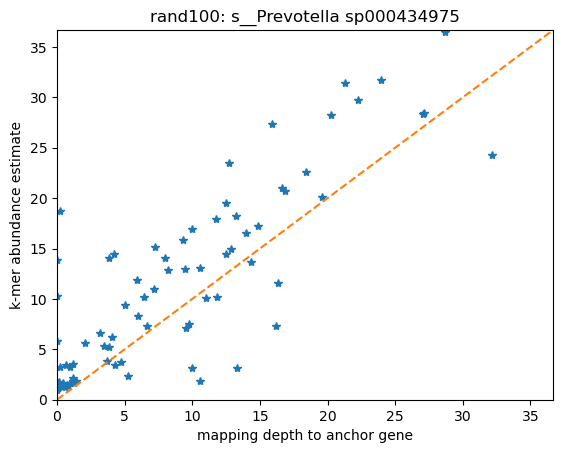

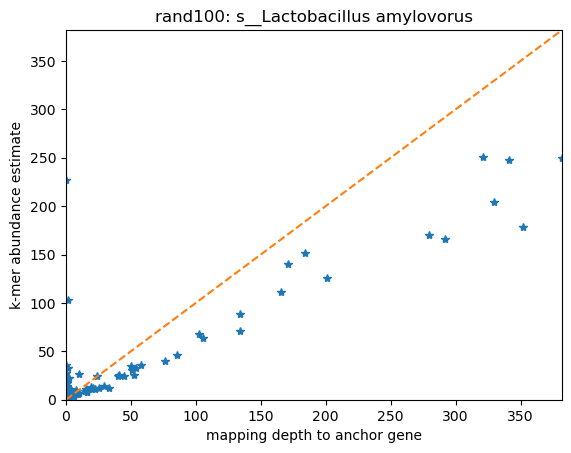

SKIPPING: s__Cryptobacteroides sp000434935


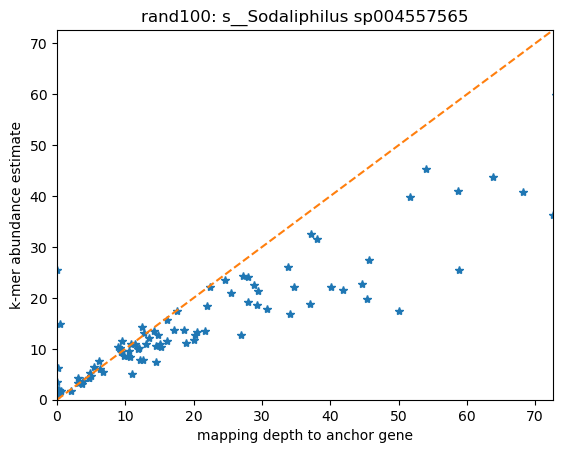

SKIPPING: s__Colivicinus sp002299675
SKIPPING: s__Ornithospirochaeta sp022785155
SKIPPING: s__Floccifex porci
SKIPPING: s__Fimisoma sp002320005


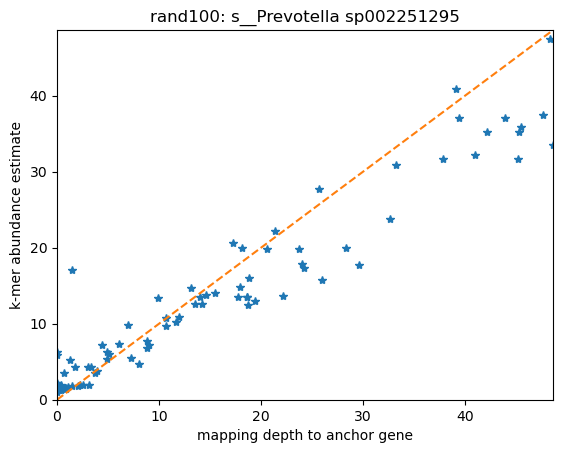

SKIPPING: s__Mogibacterium_A kristiansenii


In [9]:
## Plot for each species

for species in combo_df['species'].unique():
    xx_df = combo_df.filter(pl.col('species') == species)
    mapping_90 = list(sorted(xx_df['depth_all']))
    mapping_90 = mapping_90[int(len(mapping_90)*0.9)]

    if mapping_90 < 20:
        print('SKIPPING:', species)
        continue
    
    plt.plot(xx_df['depth_all'], xx_df['kmer_abund'], '*')
    plt.title(f'rand100: {species}')
    plt.xlabel('mapping depth to anchor gene')
    plt.ylabel('k-mer abundance estimate')
    plt.xlim(0, mapping_90)
    plt.ylim(0, mapping_90)
    plt.plot([0, mapping_90], [0, mapping_90], '--')
    plt.show()


## 
Repeat, but for highcov

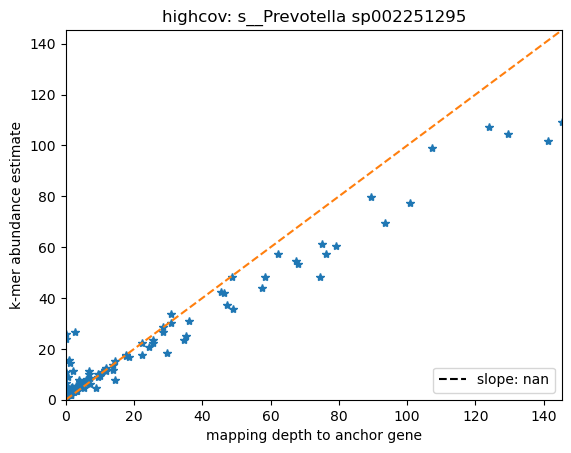

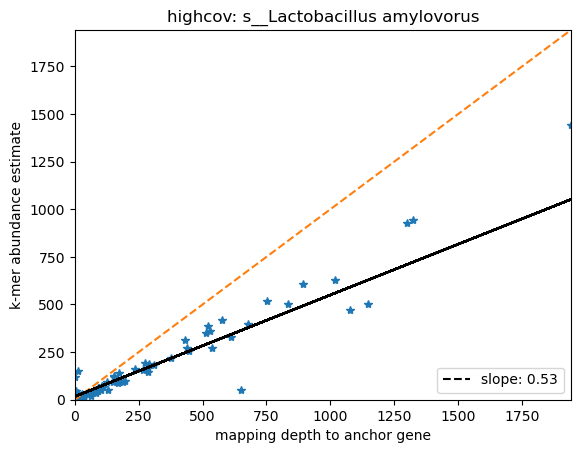

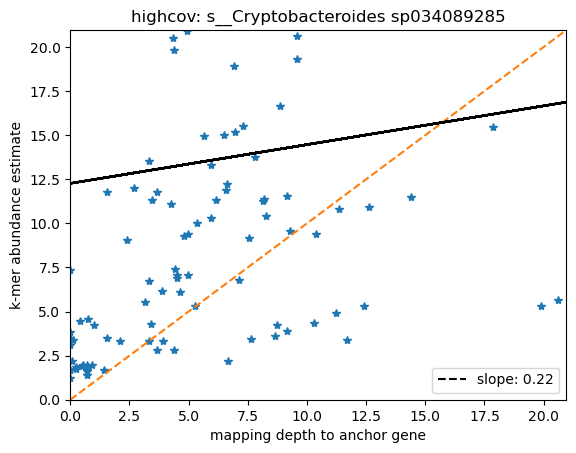

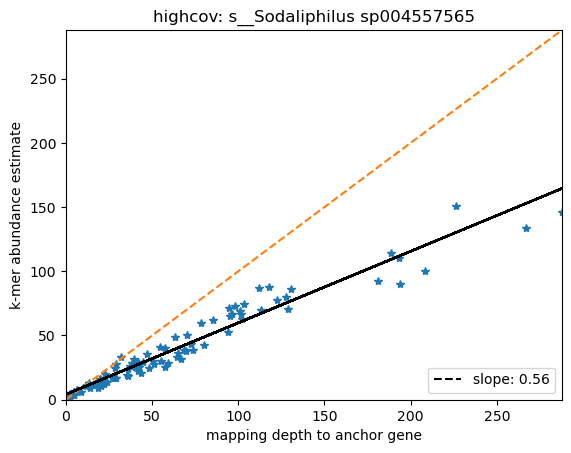

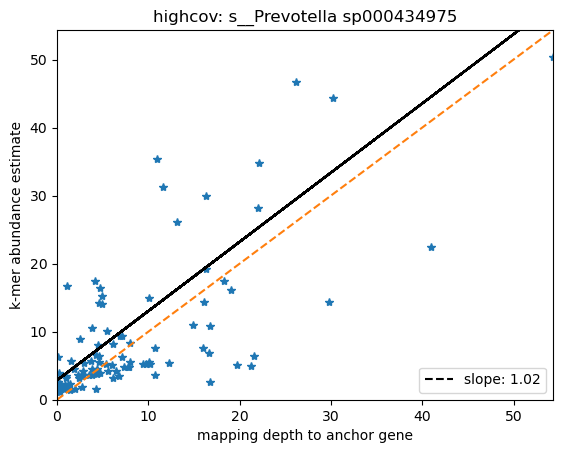

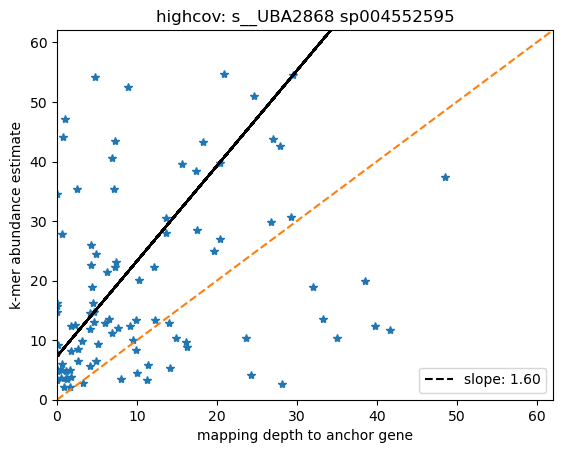

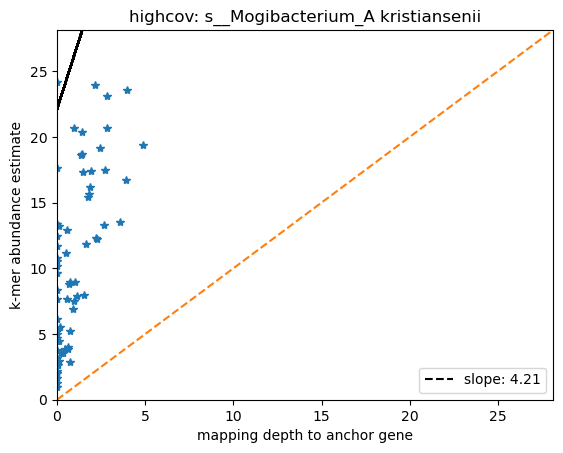

SKIPPING: s__Floccifex porci
SKIPPING: s__Colivicinus sp002299675
SKIPPING: s__Ornithospirochaeta sp022785155


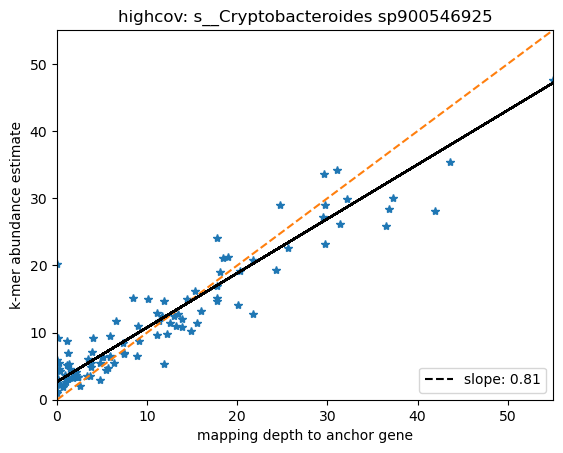

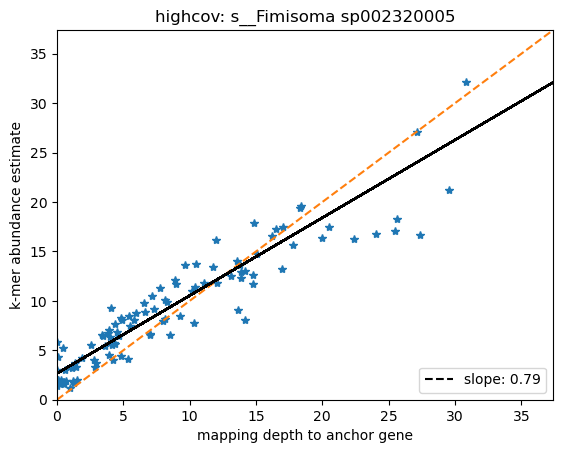

SKIPPING: s__Cryptobacteroides sp000434935


In [10]:
highcov_mapping_df = (
    pl.read_csv('../outputs.mapping/highcov-cds3.min50.depth.csv')
    .join(seq_to_species_df, on='gene', how='inner')
    .select(['metag', 'species', 'gene', 'depth_all'])
)

highcov_anchor_df = highcov_mapping_df.join(species_genes_df, on=['gene', 'species'], how='inner').drop('anchor')

highcov_combo_df = kmer_df.join(highcov_anchor_df, on=['metag', 'species'], how='inner')

## Plot for each species

for species in highcov_combo_df['species'].unique():
    xx_df = highcov_combo_df.filter(pl.col('species') == species)
    mapping_90 = list(sorted(xx_df['depth_all']))
    mapping_90 = mapping_90[int(len(mapping_90)*0.9)]

    if mapping_90 < 20:
        print('SKIPPING:', species)
        continue
    
    plt.plot(xx_df['depth_all'], xx_df['kmer_abund'], '*')
    plt.title(f'highcov: {species}')
    plt.xlabel('mapping depth to anchor gene')
    plt.ylabel('k-mer abundance estimate')
    plt.xlim(0, mapping_90)
    plt.ylim(0, mapping_90)
    plt.plot([0, mapping_90], [0, mapping_90], '--')

    coef = np.polyfit(xx_df['depth_all'], xx_df['kmer_abund'], 1)
    poly1d_fn = np.poly1d(coef) 
    plt.plot(xx_df['depth_all'], poly1d_fn(xx_df['depth_all']), '--k', label=f'slope: {coef[0]:.2f}')
    plt.legend(loc='lower right')

    #plt.plot(x, y, '.', label=f"gene {gene} fit: (slope: {coef[0]:.2f}")
    
    plt.show()


## Foo explore the bulk of genes

In [11]:
rand100_mapping_df

metag,species,gene,depth_all
str,str,str,f64
"""ERR3211766""","""s__Sodaliphilus sp004557565""","""AtH2023_SRR17241558_MAG08_494_…",2.160784
"""ERR3211766""","""s__UBA2868 sp004552595""","""AtH2023_SRR8960393_MAG18_22_28""",0.0
"""ERR3211766""","""s__Bariatricus sp004560705""","""AtH2023_SRR5240725_MAG08_283_1…",0.21393
"""ERR3211766""","""s__Sodaliphilus sp004557565""","""AtH2023_SRR11805640_MAG02_82_2""",9.953846
"""ERR3211766""","""s__Colivicinus sp002299675""","""AtH2023_SRR8960514_MAG08_39_2""",0.0
…,…,…,…
"""SRR11125751""","""s__Sodaliphilus sp004557565""","""AtH2023_SRR17241501_MAG14_158_…",17.160839
"""SRR11125751""","""s__Sodaliphilus sp004557565""","""AtH2023_SRR5976186_MAG02_155_2""",16.519298
"""SRR11125751""","""s__Cryptobacteroides sp0004349…","""AtH2023_SRR14369225_MAG28_14_6…",0.0


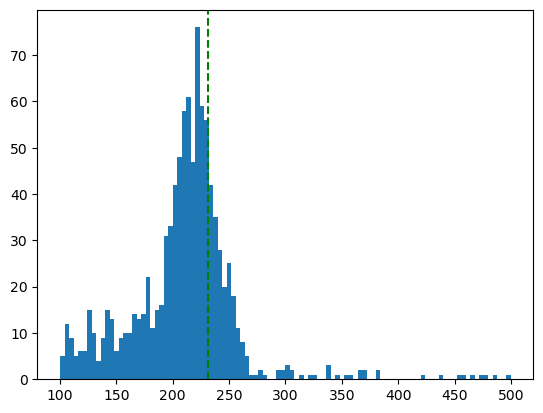

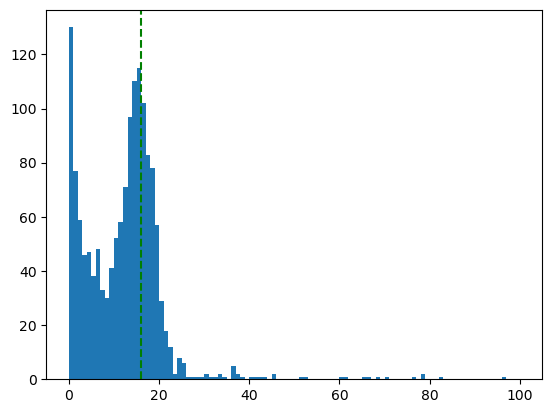

In [12]:
def plot_genes_hist(all_df, anchor_df, species, metag, *, rangex=None):
    filt = (pl.col('species') == species) & (pl.col('metag') == metag)
    xx_df = all_df.filter(filt)
    yy_df = anchor_df.filter(filt)

    plt.hist(xx_df['depth_all'], bins=100, range=rangex)
    anchor_depth = list(yy_df['depth_all'])[0]
    plt.axvline(anchor_depth, color='green', linestyle='--')
    plt.show()

plot_genes_hist(rand100_mapping_df, anchor_df, 's__Sodaliphilus sp004557565', 'SRR5240744', rangex=(100, 500))
plot_genes_hist(rand100_mapping_df, anchor_df, 's__Sodaliphilus sp004557565', 'SRR11125751', rangex=(0, 100))